RNNs, though being very <span style="color:red">expressive (can in principle be a universal approximator and be used to implement any algorithms)</span>, are not very easily optimizable with <span style="color:red">the 1st order gradient-based techniques</span>.

In [21]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [12]:
tokens = sorted(list(set(''.join(words))))   # character-level
token_to_index = {token: i+1 for i, token in enumerate(tokens)}    # a dict
token_to_index['.'] = 0
index_to_token = {i: token for token, i in token_to_index.items()}   # a dict
vocabulary_size = len(index_to_token)

In [14]:
index_to_token

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [15]:
vocabulary_size

27

In [22]:
prefix_context_length = 3

def build_set(words):
    X = []   # inputs
    Y = []   # labels

    for word in words:
        context = [0] * prefix_context_length
        for token in word + '.':
            index = token_to_index[token]
            X.append(context)
            Y.append(index)
            context = context[1:] + [index]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print('inputs shape:', X.shape, 'labels shape:', Y.shape)

    return X, Y

random.shuffle(words)
n_train = int(len(words) * 0.8)
n_train_dev = int(len(words) * 0.9)

X_train, Y_train = build_set(words[:n_train])   # 80%
X_dev, Y_dev = build_set(words[n_train:n_train_dev])   # 10%
X_test, Y_test = build_set(words[n_train_dev:])   # 10%

inputs shape: torch.Size([182430, 3]) labels shape: torch.Size([182430])
inputs shape: torch.Size([22905, 3]) labels shape: torch.Size([22905])
inputs shape: torch.Size([22811, 3]) labels shape: torch.Size([22811])


In [25]:
embedding_dimension = 10
n_hidden_neurons = 200

M = torch.randn(vocabulary_size, embedding_dimension)   # the embedding matrix
W_hidden = torch.randn(embedding_dimension * prefix_context_length, n_hidden_neurons)   # hidden layer weights
b_hidden = torch.randn(n_hidden_neurons)   # hidden layer bias
W_output = torch.randn(n_hidden_neurons, vocabulary_size)   # output layer weights
b_output = torch.randn(vocabulary_size)   # output layer bias

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

11897


In [33]:
steps = 200000
decay_at_step = int(0.5 * steps)
learning_rate_start = 0.1
learning_rate_decay = 0.1 * learning_rate_start
minibatch_size = 32

log10_minibatch_losses = []

for i in range(steps):
    minibatch_indices = torch.randint(0, X_train.shape[0], (minibatch_size,))
    X_minibatch = X_train[minibatch_indices]
    Y_minibatch = Y_train[minibatch_indices]

    # forward pass
    intput_embeddings = M[X_minibatch]
    intput_embeddings_concatenated = intput_embeddings.view(intput_embeddings.shape[0], -1)
    hidden_layer_preactivation = intput_embeddings_concatenated @ W_hidden + b_hidden
    hidden_layer_output = torch.tanh(hidden_layer_preactivation)
    logits = hidden_layer_output @ W_output + b_output
    minibatch_loss = F.cross_entropy(logits, Y_minibatch)

    # backward pass
    for p in parameters:
        p.grad = None
    minibatch_loss.backward()

    # parameter update
    learning_rate = learning_rate_start if i < decay_at_step else learning_rate_decay
    for p in parameters:
        p.data += -learning_rate * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"Loss for the minibatch at step {i} / {steps}: {minibatch_loss.item():.4f}")
    log10_minibatch_losses.append(minibatch_loss.log10().item())

Loss for the minibatch at step 0 / 200000: 30.8392
Loss for the minibatch at step 10000 / 200000: 2.8283
Loss for the minibatch at step 20000 / 200000: 2.3406
Loss for the minibatch at step 30000 / 200000: 2.4279
Loss for the minibatch at step 40000 / 200000: 2.1141
Loss for the minibatch at step 50000 / 200000: 2.6839
Loss for the minibatch at step 60000 / 200000: 2.5174
Loss for the minibatch at step 70000 / 200000: 2.4681
Loss for the minibatch at step 80000 / 200000: 2.2423
Loss for the minibatch at step 90000 / 200000: 2.4678
Loss for the minibatch at step 100000 / 200000: 2.2778
Loss for the minibatch at step 110000 / 200000: 2.4218
Loss for the minibatch at step 120000 / 200000: 2.1524
Loss for the minibatch at step 130000 / 200000: 2.1863
Loss for the minibatch at step 140000 / 200000: 2.0188
Loss for the minibatch at step 150000 / 200000: 2.1083
Loss for the minibatch at step 160000 / 200000: 1.8678
Loss for the minibatch at step 170000 / 200000: 2.2183
Loss for the minibatch 

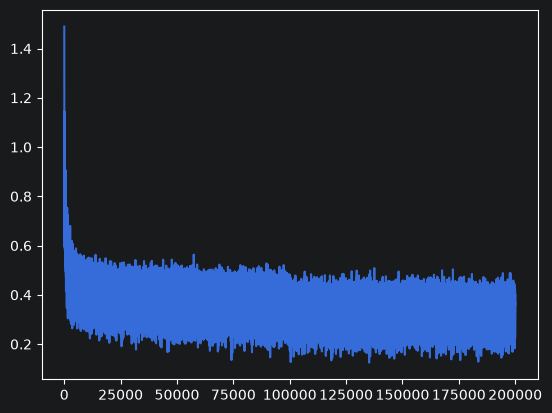

In [34]:
plt.plot(log10_minibatch_losses)

In [37]:
@torch.no_grad()   # a function's decorator: not constructing the computation graph for gradients.
def print_full_loss(split: str):
    x,y = {
        'train': (X_train, Y_train),
        'val': (X_dev, Y_dev),
        'test': (X_test, Y_test),
    }[split]

    input_embeddings = M[x]   # shape: (|x|, prefix_context_length, embedding_dimension)
    input_embeddings_concatenated = input_embeddings.view(input_embeddings.shape[0], -1)   # shape: (|x|, embedding_dimension * prefix_context_length)
    hidden_layer_output = torch.tanh(input_embeddings_concatenated @ W_hidden + b_hidden)   # shape: (|x|, n_hidden_neurons)
    logits = hidden_layer_output @ W_output + b_output   # shape: (|x|, vocabulary_size)
    full_loss = F.cross_entropy(logits, y)
    print('Full loss for the ' + split + ' set:', full_loss.item())

print_full_loss('train')
print_full_loss('val')

Full loss for the train set: 2.122344970703125
Full loss for the val set: 2.1692826747894287
